## **Load Libraries**

In [1]:
!pip install transformers datasets evaluate accelerate wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 18.9 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 14.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 15.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 16.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 kB 14.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 17.2 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 16.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 18.6 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 791.7/791.7 kB 17.9 MB/s  0:00:00
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.65.0
    Uninstalling tqdm-4.65.0:
      Successfully uninstalled tqdm-4.65.0
  Attempting uninstall: requests━━━━━━━━━━━━━━

In [18]:
import pandas as pd
import numpy as np
import torch, wandb, os, shutil, time, zipfile, re, google
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
from collections import Counter
from typing import Dict
from pathlib import Path
from tqdm import tqdm
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torch import tensor, nn
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import Dataset as TorchDataset, WeightedRandomSampler
import torch.nn.functional as F
from transformers import get_cosine_schedule_with_warmup, DataCollatorWithPadding, DistilBertForSequenceClassification, BertForSequenceClassification, BertTokenizer
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.benchmark = True

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("GPU available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
print("Current GPU:", torch.cuda.current_device())
print("GPU name:", torch.cuda.get_device_name(0))
print("Compute capability:", torch.cuda.get_device_capability(0))

GPU available: True
GPU count: 1
Current GPU: 0
GPU name: NVIDIA H100 80GB HBM3
Compute capability: (9, 0)


## **Data Processing**

### Loading dataset

In [6]:
# load dataset from hugging face
dataset = load_dataset("SetFit/20_newsgroups")
df = pd.concat([dataset['train'].to_pandas(), dataset['test'].to_pandas()], ignore_index=True)

print(f"Columns: {list(df.columns)}")
print(f"Shape: {df.shape}")
df.head()

[2026-03-17 12:25:51,363] INFO httpx: HTTP Request: HEAD https://huggingface.co/datasets/SetFit/20_newsgroups/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
[2026-03-17 12:25:51,370] INFO httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/SetFit/20_newsgroups/f1b91292074e7cfb69be58b642d583ec262f30ed/README.md "HTTP/1.1 200 OK"
[2026-03-17 12:25:51,377] INFO httpx: HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/SetFit/20_newsgroups/f1b91292074e7cfb69be58b642d583ec262f30ed/README.md "HTTP/1.1 200 OK"


README.md:   0%|          | 0.00/734 [00:00<?, ?B/s]

[2026-03-17 12:25:51,639] INFO httpx: HTTP Request: HEAD https://huggingface.co/datasets/SetFit/20_newsgroups/resolve/f1b91292074e7cfb69be58b642d583ec262f30ed/20_newsgroups.py "HTTP/1.1 404 Not Found"


Repo card metadata block was not found. Setting CardData to empty.


[2026-03-17 12:25:52,384] INFO httpx: HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/SetFit/20_newsgroups/SetFit/20_newsgroups.py "HTTP/1.1 404 Not Found"
[2026-03-17 12:25:52,386] WARNING huggingface_hub.repocard: Repo card metadata block was not found. Setting CardData to empty.
[2026-03-17 12:25:52,643] INFO httpx: HTTP Request: GET https://huggingface.co/api/datasets/SetFit/20_newsgroups/revision/f1b91292074e7cfb69be58b642d583ec262f30ed "HTTP/1.1 200 OK"
[2026-03-17 12:25:52,898] INFO httpx: HTTP Request: HEAD https://huggingface.co/datasets/SetFit/20_newsgroups/resolve/f1b91292074e7cfb69be58b642d583ec262f30ed/.huggingface.yaml "HTTP/1.1 404 Not Found"
[2026-03-17 12:25:53,202] INFO httpx: HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=SetFit/20_newsgroups "HTTP/1.1 200 OK"
[2026-03-17 12:25:53,456] INFO httpx: HTTP Request: GET https://huggingface.co/api/datasets/SetFit/20_newsgroups/tree/f1b91292074e7cfb69be58b642d583e

...

test.jsonl:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

Columns: ['text', 'label', 'label_text']
Shape: (18846, 3)


,text,label,label_text
0,I was wondering if anyone out there could enli...,7,rec.autos
1,A fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the gh...",4,comp.sys.mac.hardware
3,\nDo you have Weitek's address/phone number? ...,1,comp.graphics
4,"From article <C5owCB.n3p@world.std.com>, by to...",14,sci.space


### EDA on dataset

#### Dataset statistics

In [8]:
print(f"\nNumber of classes (corpus):  {df['label_text'].nunique()}")
print(f"Total documents:             {len(df):,}")
print(f"  - Train split:             {len(dataset['train']):,}")
print(f"  - Test split:              {len(dataset['test']):,}")

# Documents per corpus
print("\nDOCUMENTS PER CORPUS")
class_counts = df['label_text'].value_counts().sort_index()
for name, count in class_counts.items():
    print(f"  {name:<30s} {count:>5}")

print(f"\nMin:  {class_counts.min():>5}  ({class_counts.idxmin()})")
print(f"Max:  {class_counts.max():>5}  ({class_counts.idxmax()})")
print(f"Mean: {class_counts.mean():>8.1f}")
print(f"Std:  {class_counts.std():>8.1f}")


Number of classes (corpus):  20
Total documents:             18,846
  - Train split:             11,314
  - Test split:              7,532

DOCUMENTS PER CORPUS
  alt.atheism                      799
  comp.graphics                    973
  comp.os.ms-windows.misc          985
  comp.sys.ibm.pc.hardware         982
  comp.sys.mac.hardware            963
  comp.windows.x                   988
  misc.forsale                     975
  rec.autos                        990
  rec.motorcycles                  996
  rec.sport.baseball               994
  rec.sport.hockey                 999
  sci.crypt                        991
  sci.electronics                  984
  sci.med                          990
  sci.space                        987
  soc.religion.christian           997
  talk.politics.guns               910
  talk.politics.mideast            940
  talk.politics.misc               775
  talk.religion.misc               628

Min:    628  (talk.religion.misc)
Max:    999  (rec.sport

#### Token stattistics

In [9]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(lambda x: len(str(x)))

print("### TOKEN / WORD STATISTICS ###")
print(f"Total words in corpus:      {df['word_count'].sum():>12,}")
print(f"Total characters in corpus: {df['char_count'].sum():>12,}")

print(f"\nPer-document word count:")
print(f"  Mean:   {df['word_count'].mean():>10.1f}")
print(f"  Median: {df['word_count'].median():>10.1f}")
print(f"  Std:    {df['word_count'].std():>10.1f}")
print(f"  Min:    {df['word_count'].min():>10}")
print(f"  Max:    {df['word_count'].max():>10}")
print(f"  Q25:    {df['word_count'].quantile(0.25):>10.0f}")
print(f"  Q75:    {df['word_count'].quantile(0.75):>10.0f}")

### TOKEN / WORD STATISTICS ###
Total words in corpus:         3,423,145
Total characters in corpus:   22,043,554

Per-document word count:
  Mean:        181.6
  Median:       83.0
  Std:         501.3
  Min:             0
  Max:         11765
  Q25:            40
  Q75:           166


#### Visuatlization

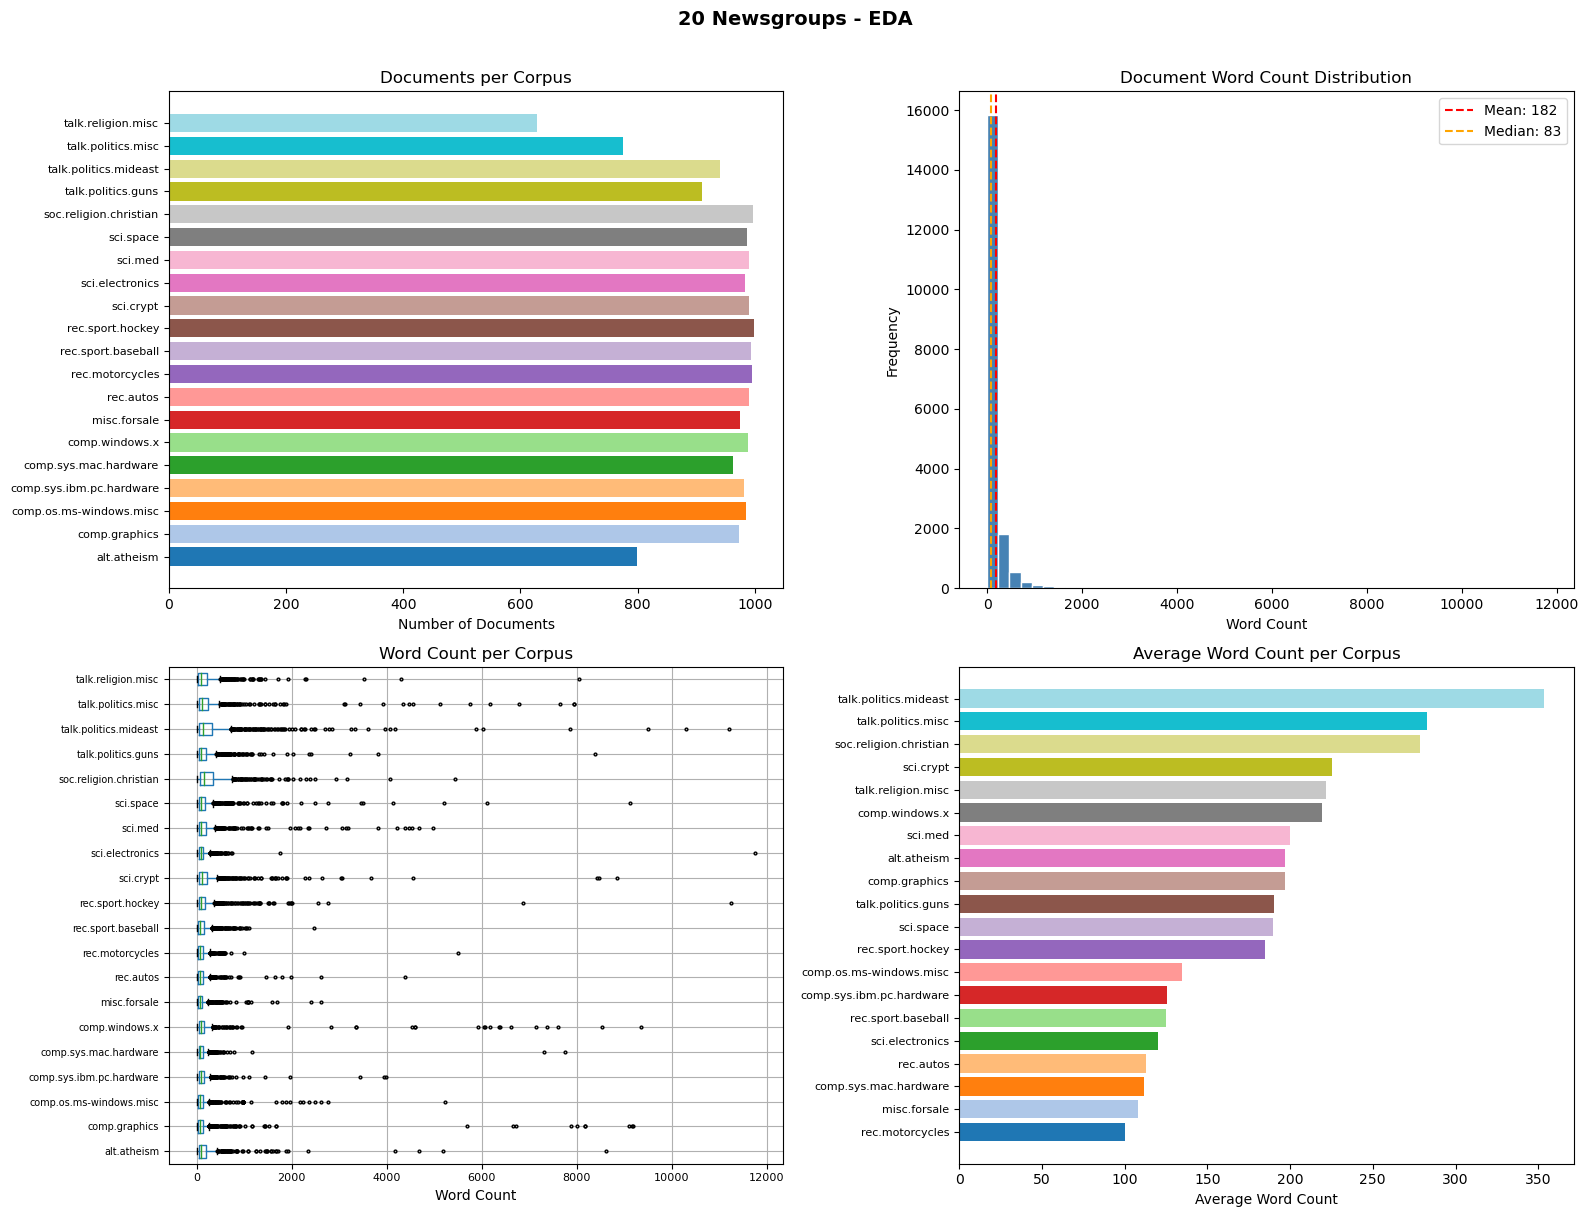

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Documents per corpus
ax = axes[0, 0]
class_counts = df['label_text'].value_counts().sort_index()
colors = plt.cm.tab20(range(20))
ax.barh(range(len(class_counts)), class_counts.values, color=colors)
ax.set_yticks(range(len(class_counts)))
ax.set_yticklabels(class_counts.index, fontsize=8)
ax.set_xlabel('Number of Documents')
ax.set_title('Documents per Corpus')

# Word count distribution
ax = axes[0, 1]
ax.hist(df['word_count'], bins=50, color='steelblue', edgecolor='white')
ax.axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["word_count"].mean():.0f}')
ax.axvline(df['word_count'].median(), color='orange', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Document Word Count Distribution')
ax.legend()

# Boxplot of word count per corpus
ax = axes[1, 0]
df.boxplot(column='word_count', by='label_text', ax=ax, vert=False, flierprops=dict(markersize=2))
ax.set_xlabel('Word Count')
ax.set_title('Word Count per Corpus')
plt.sca(ax)
plt.ylabel('')
plt.xticks(fontsize=8)
plt.yticks(fontsize=7)

# Average word count per corpus
ax = axes[1, 1]
avg_wc = df.groupby('label_text')['word_count'].mean().sort_values()
ax.barh(range(len(avg_wc)), avg_wc.values, color=colors)
ax.set_yticks(range(len(avg_wc)))
ax.set_yticklabels(avg_wc.index, fontsize=8)
ax.set_xlabel('Average Word Count')
ax.set_title('Average Word Count per Corpus')

plt.suptitle('20 Newsgroups - EDA', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Preprocessing

In [11]:
### truncate and clean input corpus
MAX_WORDS = 400
def truncate_text(text, max_words=MAX_WORDS):
    words = str(text).split()
    if len(words) > max_words:
        return ' '.join(words[:max_words])
    return text

def clean_text(text):
    lines = text.split('\n')
    cleaned = []
    for line in lines:
        # Skip quoted text
        stripped = line.strip()
        if stripped.startswith('>') or stripped.startswith(':') or stripped.startswith('|'):
            continue
        # Skip email headers
        if any(line.startswith(h) for h in ['From:', 'Subject:', 'Organization:',
                                            'Lines:', 'Reply-To:', 'NNTP-Posting-Host:']):
            continue
        # Skip "--"
        if line.strip() == '--':
            break
        cleaned.append(line)
    clean_text = ' '.join(cleaned).strip()
    clean_text = re.sub(r'http\S+|ftp\S+|www\.\S+', '', text)               # URLs
    clean_text = re.sub(r'\S+@\S+', '', clean_text)                         # emails
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()                    # collapse whitespace
    clean_text = re.sub(r'\[.*?deletia.*?\]', '', clean_text, flags=re.IGNORECASE)
    clean_text = re.sub(r'\[.*?snip.*?\]', '', clean_text, flags=re.IGNORECASE)
    return clean_text

train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()
train_df['text_clean'] = train_df['text'].apply(clean_text).apply(truncate_text)
test_df['text_clean'] = test_df['text'].apply(clean_text).apply(truncate_text)

# handle len(text) < min length
min_length = 100

train_df = train_df[train_df['text_clean'].str.len() >= min_length]
test_df = test_df[test_df['text_clean'].str.len() >= min_length]

# Split train -> train + val (80/20)
train_df, val_df = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df['label']
)

print(f"Train: {len(train_df)}          Percentage: {len(train_df) / len(df) * 100:.2f}%")
print(f"Val:   {len(val_df)}           Percentage: {len(val_df) / len(df) * 100:.2f}%")
print(f"Test:  {len(test_df)}           Percentage: {len(test_df) / len(df)*100:.2f}%")

# re-check
short_per_class = {}
for df_split, df_name in [(train_df, 'train'), (val_df, 'val'), (test_df, 'test')]:
    short_mask = df_split['text_clean'].str.len() < min_length
    short_per_class[df_name] = df_split.loc[short_mask, 'label_text'].value_counts().to_dict()

print("Short docs per class:", short_per_class)


Train: 8201          Percentage: 43.52%
Val:   2051           Percentage: 10.88%
Test:  6757           Percentage: 35.85%
Short docs per class: {'train': {}, 'val': {}, 'test': {}}


In [12]:
# tokenize texts
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_LENGTH = 512
def tokenize_fn(df):
    return tokenizer(
        df['text_clean'],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_ds = Dataset.from_pandas(train_df[['text_clean', 'label']].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[['text_clean', 'label']].reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df[['text_clean', 'label']].reset_index(drop=True))

print("Tokenizing...")
train_ds = train_ds.map(tokenize_fn, batched=True, batch_size=256).rename_column("label", "labels")
val_ds   = val_ds.map(tokenize_fn, batched=True, batch_size=256).rename_column("label", "labels")
test_ds  = test_ds.map(tokenize_fn, batched=True, batch_size=256).rename_column("label", "labels")

print(f"\nTrain: {train_ds}")
print(f"Val:   {val_ds}")
print(f"Test:  {test_ds}")

[2026-03-17 12:27:18,975] INFO httpx: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
[2026-03-17 12:27:18,976] WARNING huggingface_hub.utils._http: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
[2026-03-17 12:27:19,245] INFO httpx: HTTP Request: GET https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

[2026-03-17 12:27:19,514] INFO httpx: HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
[2026-03-17 12:27:19,771] INFO httpx: HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
[2026-03-17 12:27:20,029] INFO httpx: HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
[2026-03-17 12:27:20,286] INFO httpx: HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
[2026-03-17 12:27:20,549] INFO httpx: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/vocab.txt "HTTP/1.1 200 OK"
[2026-03-17 12:27:20,807] INFO httpx: HTTP Request: GET https://huggingface.co/bert-base

vocab.txt: 0.00B [00:00, ?B/s]

[2026-03-17 12:27:21,077] INFO httpx: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 200 OK"
[2026-03-17 12:27:21,335] INFO httpx: HTTP Request: GET https://huggingface.co/bert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 200 OK"


...

[2026-03-17 12:27:21,711] INFO httpx: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/added_tokens.json "HTTP/1.1 404 Not Found"
[2026-03-17 12:27:21,971] INFO httpx: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/special_tokens_map.json "HTTP/1.1 404 Not Found"
[2026-03-17 12:27:22,234] INFO httpx: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
Tokenizing...


Map:   0%|          | 0/8201 [00:00<?, ? examples/s]

Map:   0%|          | 0/2051 [00:00<?, ? examples/s]

Map:   0%|          | 0/6757 [00:00<?, ? examples/s]


Train: Dataset({
    features: ['text_clean', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 8201
})
Val:   Dataset({
    features: ['text_clean', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2051
})
Test:  Dataset({
    features: ['text_clean', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6757
})


In [13]:
# final process ds
if 'text_clean' in train_ds.column_names:
    train_ds = train_ds.remove_columns(['text_clean'])
if 'text_clean' in val_ds.column_names:
    val_ds   = val_ds.remove_columns(['text_clean'])
if 'text_clean' in test_ds.column_names:
    test_ds  = test_ds.remove_columns(['text_clean'])

# rm token_type_ids: no need in classification task
if 'token_type_ids' in train_ds.column_names:
    train_ds = train_ds.remove_columns(['token_type_ids'])
if 'token_type_ids' in val_ds.column_names:
    val_ds   = val_ds.remove_columns(['token_type_ids'])
if 'token_type_ids' in test_ds.column_names:
    test_ds  = test_ds.remove_columns(['token_type_ids'])


print(f"\nTrain: {train_ds}")
print(f"Val:   {val_ds}")
print(f"Test:  {test_ds}")


Train: Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 8201
})
Val:   Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 2051
})
Test:  Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 6757
})


### Post-Tokenization with first 500 samples ###
  Mean:   193.0
  Median: 145.0
  Max:    512
  % hitting 512 cap: 6.6%


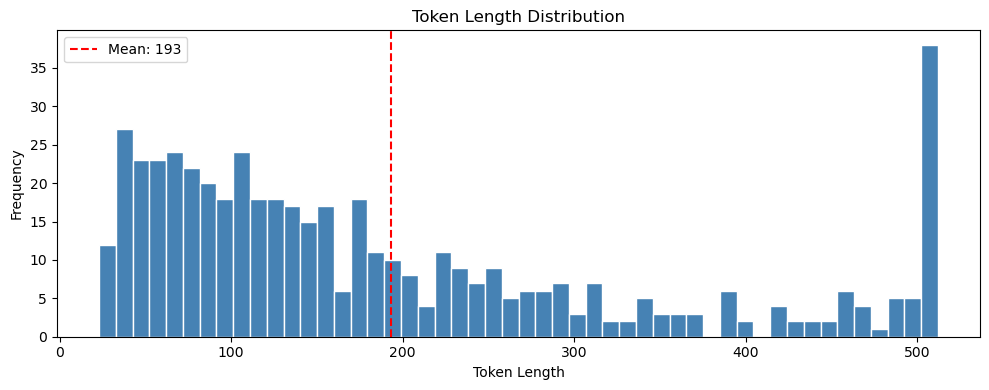

In [14]:
# verify tokens
sample_sizes = min(500, len(train_ds))
token_lengths = []
for i in range(sample_sizes):
    ids = train_ds[i]['input_ids']
    token_lengths.append(len(ids))

print("### Post-Tokenization with first 500 samples ###")
print(f"  Mean:   {np.mean(token_lengths):.1f}")
print(f"  Median: {np.median(token_lengths):.1f}")
print(f"  Max:    {np.max(token_lengths)}")
print(f"  % hitting 512 cap: {sum(1 for t in token_lengths if t >= 512) / len(token_lengths) * 100:.1f}%")

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.mean(token_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(token_lengths):.0f}')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.title('Token Length Distribution')
plt.legend()
plt.tight_layout()
plt.show()

### Handle imbalanced weights of classes

In [ ]:
train_labels = torch.tensor(train_ds['labels'])

class_counts = torch.bincount(train_labels)
num_classes = len(class_counts)
total_samples = len(train_labels)

# class weights = N / num_labels * n_i
class_weights = total_samples / (num_classes * class_counts).float().to(device)
print("Class weights:", class_weights)


Class weights: tensor([1.1817, 0.9786, 0.9603, 0.9235, 1.0001, 0.9215, 0.9581, 0.9977, 1.0075,
        1.0175, 0.9514, 0.9256, 0.9492, 0.9173, 0.9383, 0.9012, 1.0125, 1.0001,
        1.2096, 1.5711], device='cuda:0')


## **Building and Training model**

### Transformer: BERT and DistilBERT

#### Helper functions

In [32]:
# log function for wandb
def log_gradients_and_weights(model, step, log_interval=50):
    if step % log_interval != 0:
        return

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        # Gradient norm 
        if param.grad is not None:
            wandb.log({
                f"grad_norm/{name}": param.grad.norm().item(),
                "step": step
            })

        # Weight 
        wandb.log({
            f"weight_mean/{name}": param.data.mean().item(),
            f"weight_std/{name}": param.data.std().item(),
            "step": step
        })

# training function
def training(model, loader, optimizer, scheduler, device, class_weights, max_grad_norm, log_interval=50):
    model.train()
    total_loss = 0 
    loss_function = CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    progress = tqdm(loader, desc="Training", leave=True)
    global_step = 0

    for batch in progress:
        # move to gpu
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        label = batch['labels'].to(device)

        # forward
        optimizer.zero_grad() # clean grad
        outputs = model(input_ids=input_ids, attention_mask=attention_mask) # logits
        loss = loss_function(outputs.logits, label)
        
        # backward
        loss.backward()
        total_norm = clip_grad_norm_(model.parameters(), max_grad_norm) # limit magnitude of gradient
        wandb.log({"grad_norm_before_clip": total_norm.item()})

        # log grad and weight
        log_gradients_and_weights(model, global_step, log_interval)
        global_step += 1
        
        # update hyparameters
        optimizer.step() # weight
        scheduler.step() # learning rate
        total_loss += loss.item()
        progress.set_postfix({'loss': f'{loss.item():.4f}'})
    return total_loss / len(loader)

# function for evaluating accuracy of model validation set
def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    progress = tqdm(loader, desc="Evaluating", leave=False)
    with torch.no_grad(): 
        for batch in progress :
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels']

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()   # convert to cpu to compute

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
    return accuracy

# choose 1 of 2 transformer models
def setup_model(model_name, num_labels=20, dropout=0.1):
    if model_name == 'distilbert-base-uncased':
        model = DistilBertForSequenceClassification.from_pretrained(
            model_name, num_labels=num_labels,
            seq_classif_dropout=dropout
        )
        # DistilBERT has pre_classifier
        model_type = 'distilbert'
    elif model_name == 'bert-base-uncased':
        model = BertForSequenceClassification.from_pretrained(
            model_name, num_labels=num_labels,
            hidden_dropout_prob=dropout,
            attention_probs_dropout_prob=dropout
        )
        # BERT has pooler
        model_type = 'bert'
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model, model_type

# get approriate hyparameters for separated models
def get_param_groups(model, model_type, strategy, lr_head=5e-5, lr_encoder=1e-6):
    param_groups = []
    if model_type == 'distilbert':
        if strategy == 'full_fine_tune':
            param_groups = [
                {'params': model.distilbert.embeddings.parameters(), 'lr': lr_encoder}, # dont need to learn new features -> low lr
                {'params': model.distilbert.transformer.layer[:3].parameters(), 'lr': lr_encoder * 2},
                {'params': model.distilbert.transformer.layer[3:].parameters(), 'lr': lr_encoder * 5},  # learn and extract new features -> high lr
                {'params': model.pre_classifier.parameters(), 'lr': lr_head},
                {'params': model.classifier.parameters(), 'lr': lr_head},
            ]
        elif strategy == 'freeze_backbone':
            # Only classifier + pre_classifier
            param_groups = [
                {'params': model.pre_classifier.parameters(), 'lr': lr_head},
                {'params': model.classifier.parameters(), 'lr': lr_head},
            ]
        elif strategy == 'hybrid':
            # Phase 1: head only, Phase 2: full
            param_groups = 'hybrid' 

    elif model_type == 'bert':
        if strategy == 'full_fine_tune':
            param_groups = [
                {'params': model.bert.embeddings.parameters(), 'lr': lr_encoder},
                {'params': model.bert.encoder.layer[:6].parameters(), 'lr': lr_encoder * 2},
                {'params': model.bert.encoder.layer[6:].parameters(), 'lr': lr_encoder * 5},
                {'params': model.bert.pooler.parameters(), 'lr': lr_head},
                {'params': model.classifier.parameters(), 'lr': lr_head},
            ]
        elif strategy == 'freeze_backbone':
            param_groups = [
                {'params': model.bert.pooler.parameters(), 'lr': lr_head},
                {'params': model.classifier.parameters(), 'lr': lr_head},
            ]
        elif strategy == 'hybrid':
            param_groups = 'hybrid'

    return param_groups

# freeze backbone
def freeze_backbone(model, model_type):
    if model_type == 'distilbert':
        for param in model.distilbert.parameters():
            param.requires_grad = False
    elif model_type == 'bert':
        for param in model.bert.parameters():
            param.requires_grad = False

# unfreeze head
def unfreeze_head(model, model_type):
    if model_type == 'distilbert':
        for param in model.pre_classifier.parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True
    elif model_type == 'bert':
        if model.bert.pooler is not None:
            for param in model.bert.pooler.parameters():
                param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

# unfreeze backbone+head
def unfreeze_all(model, model_type):
    if model_type == 'distilbert':
        for param in model.distilbert.parameters():
            param.requires_grad = True
    elif model_type == 'bert':
        for param in model.bert.parameters():
            param.requires_grad = True

# full train
def train_full(model, train_loader, val_loader, optimizer, scheduler, epochs, max_grad_norm, save_path='./best_model.pt'):
    best_acc = 0.0
    for epoch in range(epochs):
        train_loss = training(model, train_loader, optimizer, scheduler, device, class_weights, max_grad_norm)
        val_acc = evaluate(model, val_loader, device)

        wandb.log({'train_loss': train_loss, 'val_accuracy': val_acc, 'epoch': epoch})

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)

    return best_acc


#### Train model

In [33]:
# dataloader
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
train_loader = DataLoader(train_ds, batch_size=12, shuffle=True, collate_fn=data_collator, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=36, shuffle=False, collate_fn=data_collator)
test_loader = DataLoader(test_ds, batch_size=36, shuffle=True, collate_fn=data_collator)

configs = {
    'distilbert': {
        'model_name': 'distilbert-base-uncased',
        'dropout': 0.1,
    },
    'bert': {
        'model_name': 'bert-base-uncased',
        'dropout': 0.1,
    },
}

strategies = ['freeze_backbone', 'hybrid', 'full_fine_tune']

# Training params
epochs_1 = 5   # for hybrid: head training
epochs_2 = 15  # for hybrid: full fine-tune OR full fine-tune only
batch_size = 12
max_grad_norm = 5.0
max_length = 512

# run experiment
results = {}

for model_key in ['distilbert', 'bert']:
    config = configs[model_key]
    results[model_key] = {}

    for strategy in strategies:
        wandb.init(
            project="20-newsgroups-comparison",
            name=f"{model_key}_{strategy}",
            reinit=True
        )
        
        print(f"\n{'='*50}")
        print(f"Model: {model_key}, Strategy: {strategy}")
        print('='*50)

        # Reset model
        model, model_type = setup_model(config['model_name'], num_labels=20, dropout=config['dropout'])
        model = model.to(device)
        best_acc = 0.0
        save_path = f'./best_model_{model_key}_{strategy}.pt'
        
        # start training time
        start_time = time.time()
        
        if strategy == 'freeze_backbone':
            # Train only classifier
            freeze_backbone(model, model_type)
            unfreeze_head(model, model_type)
            optimizer = AdamW(get_param_groups(model, model_type, strategy), lr=5e-5)
            scheduler = get_cosine_schedule_with_warmup(optimizer, 200, len(train_loader) * epochs_2)

            best_acc = train_full(model, train_loader, val_loader, optimizer, scheduler, epochs_2, max_grad_norm, save_path) 

        elif strategy == 'hybrid':
            # Phase 1: train head only
            freeze_backbone(model, model_type)
            unfreeze_head(model, model_type)

            optimizer = AdamW(get_param_groups(model, model_type, 'freeze_backbone'), lr=5e-5)
            scheduler = get_cosine_schedule_with_warmup(optimizer, 200, len(train_loader) * epochs_1)

            train_full(model, train_loader, val_loader, optimizer, scheduler, epochs_1, max_grad_norm, save_path)

            # Phase 2: unfreeze backbone
            unfreeze_all(model, model_type)
            optimizer = AdamW(get_param_groups(model, model_type, 'full_fine_tune'), lr=5e-5)
            scheduler = get_cosine_schedule_with_warmup(optimizer, 500, len(train_loader) * epochs_2)

            best_acc = train_full(model, train_loader, val_loader, optimizer, scheduler, epochs_2, max_grad_norm, save_path)

        elif strategy == 'full_fine_tune':
            # Train everything from start
            optimizer = AdamW(get_param_groups(model, model_type, strategy), lr=5e-5)
            scheduler = get_cosine_schedule_with_warmup(optimizer, 500, len(train_loader) * epochs_2)

            best_acc = train_full(model, train_loader, val_loader, optimizer, scheduler, epochs_2, max_grad_norm, save_path)

        # finish training
        wandb.finish()
        train_time = time.time() - start_time
        
        # save best model
        model.load_state_dict(torch.load(save_path))
        test_acc = evaluate(model, test_loader, device)
        
        # Inference time
        model.eval()
        times = []
        with torch.no_grad():
            for i, batch in enumerate(test_loader):
                if i >= 50: break
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                start = time.time()
                _ = model(input_ids=input_ids, attention_mask=attention_mask)
                torch.cuda.synchronize()
                times.append(time.time() - start)

        # Model size
        param_count = sum(p.numel() for p in model.parameters())
        model_size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024**2)

        results[model_key][strategy] = {
            'best_val_acc': best_acc,
            'test_acc': test_acc,
            'train_time_sec': train_time,
            'inference_ms': np.mean(times) * 1000,
            'params': param_count,
            'size_mb': model_size_mb,
        }
        
        print(f"  Best Val Acc: {best_acc:.4f}")
        print(f"  Test Acc: {test_acc:.4f}")
        print(f"  Train Time: {train_time:.0f}s")
        print(f"  Inference: {np.mean(times)*1000:.1f}ms")

wandb: Finishing previous runs because reinit is set to True.
wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading summary, console lines 25-28
wandb: 🚀 View run distilbert_freeze_backbone at: https://wandb.ai/nguyenquochieujff7-ho-chi-minh-city-university-of-technology/20-newsgroups-comparison/runs/zbcpek8h
wandb: ⭐️ View project at: https://wandb.ai/nguyenquochieujff7-ho-chi-minh-city-university-of-technology/20-newsgroups-comparison
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260317_124203-zbcpek8h/logs
wandb: setting up run 1a1t0y90
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /home/jovyan/wandb/run-20260317_124416-1a1t0y90
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run distilbert_freeze_backbone
wandb: ⭐️ View project at https://wandb.ai/nguyenquochieujff7-ho-chi-minh-city-univ


Model: distilbert, Strategy: freeze_backbone
[2026-03-17 12:44:21,633] INFO httpx: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
[2026-03-17 12:44:21,898] INFO httpx: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Training: 100%|██████████| 683/683 [00:15<00:00, 43.38it/s, loss=1.5822]
wandb: updating run metadata                  
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading output.log; uplo

  Best Val Acc: 0.6738
  Test Acc: 0.6615
  Train Time: 292s
  Inference: 44.3ms


...

wandb: setting up run ciqjxpoq
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /home/jovyan/wandb/run-20260317_134437-ciqjxpoq
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run bert_full_fine_tune
wandb: ⭐️ View project at https://wandb.ai/nguyenquochieujff7-ho-chi-minh-city-university-of-technology/20-newsgroups-comparison
wandb: 🚀 View run at https://wandb.ai/nguyenquochieujff7-ho-chi-minh-city-university-of-technology/20-newsgroups-comparison/runs/ciqjxpoq



Model: bert, Strategy: full_fine_tune
[2026-03-17 13:44:38,487] INFO httpx: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
[2026-03-17 13:44:38,754] INFO httpx: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Training: 100%|██████████| 683/683 [0

  Best Val Acc: 0.7996
  Test Acc: 0.7417
  Train Time: 1168s
  Inference: 87.9ms


#### Visualization

In [34]:
# Print comparison table
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"{'Model':<15} {'Strategy':<20} {'Val Acc':<10} {'Test Acc':<10} {'Time(s)':<10} {'Inf(ms)':<10} {'Params':<15}")
print("-"*80)
for model_key in results:
    for strategy in results[model_key]:
        r = results[model_key][strategy]
        print(f"{model_key:<15} {strategy:<20} {r['best_val_acc']:.4f}    {r['test_acc']:.4f} {r['train_time_sec']:.0f}       {r['inference_ms']:.1f}      {r['params']:,}")


RESULTS SUMMARY
Model           Strategy             Val Acc    Test Acc   Time(s)    Inf(ms)    Params         
--------------------------------------------------------------------------------
distilbert      freeze_backbone      0.6738    0.6615 292       44.3      66,968,852
distilbert      hybrid               0.7889    0.7388 735       44.1      66,968,852
distilbert      full_fine_tune       0.7933    0.7406 644       44.4      66,968,852
bert            freeze_backbone      0.6480    0.6293 501       88.2      109,497,620
bert            hybrid               0.7986    0.7477 1337       88.3      109,497,620
bert            full_fine_tune       0.7996    0.7417 1168       87.9      109,497,620


In [49]:
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Predicting", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].numpy())

    return np.array(all_preds), np.array(all_labels)


def visualize_results(all_preds, all_labels, class_names, model_name="Model"):
    # Get classification report as dict
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True,zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    # Extract per-class metrics
    precision = [report[c]['precision'] for c in class_names]
    recall = [report[c]['recall'] for c in class_names]
    f1 = [report[c]['f1-score'] for c in class_names]

    fig, axes = plt.subplots(2, 2, figsize=(20, 16))

    # 1. Per-Class Metrics Bar Chart
    ax = axes[0, 0]
    x = np.arange(len(class_names))
    width = 0.25
    ax.bar(x - width, precision, width, label='Precision', color='steelblue')
    ax.bar(x, recall, width, label='Recall', color='coral')
    ax.bar(x + width, f1, width, label='F1-Score', color='seagreen')
    ax.set_xlabel('Class')
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name} - Per-Class Metrics', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
    ax.legend(loc='upper right')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)

    # 2. Confusion Matrix
    ax = axes[0, 1]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{model_name} - Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(class_names, rotation=0, fontsize=7)

    # 3. F1 Scores Sorted
    ax = axes[1, 0]
    sorted_indices = np.argsort(f1)
    sorted_classes = [class_names[i] for i in sorted_indices]
    sorted_f1 = [f1[i] for i in sorted_indices]
    colors = ['red' if x < 0.5 else 'orange' if x < 0.7 else 'green' for x in sorted_f1]
    ax.barh(range(len(sorted_classes)), sorted_f1, color=colors)
    ax.set_yticks(range(len(sorted_classes)))
    ax.set_yticklabels(sorted_classes, fontsize=8)
    ax.set_xlabel('F1-Score')
    ax.set_title(f'{model_name} - F1 Scores (Sorted)', fontsize=13, fontweight='bold')
    ax.axvline(x=0.7, color='gray', linestyle='--', alpha=0.5, label='Threshold 0.7')
    ax.legend()
    ax.set_xlim(0, 1)

    # 4. Overall Metrics
    ax = axes[1, 1]
    overall_metrics = {
        'Accuracy': report['accuracy'],
        'F1 Macro': report['macro avg']['f1-score'],
        'F1 Weighted': report['weighted avg']['f1-score'],
        'Precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
    }
    bars = ax.bar(overall_metrics.keys(), overall_metrics.values(),
                color=['steelblue', 'coral', 'seagreen', 'mediumpurple', 'goldenrod'])
    ax.set_ylim(0, 1)
    ax.set_title(f'{model_name} - Overall Metrics', fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    for bar, val in zip(bars, overall_metrics.values()):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2%}',
                ha='center', fontsize=11, fontweight='bold')

    plt.suptitle(f'{model_name} - Classification Report', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"\n{'='*50}")
    print(f"{model_name} - Summary")
    print(f"{'='*50}")
    for k, v in overall_metrics.items():
        print(f"  {k:<15}: {v:.4f}")
    print(f"\n  Best class:  {sorted_classes[-1]} (F1: {sorted_f1[-1]:.2f})")
    print(f"  Worst class: {sorted_classes[0]} (F1: {sorted_f1[0]:.2f})")


In [ ]:
dBhy_model = DistilBertForSequenceClassification.from_pretrained(
    distilbert-base-uncased, num_labels=20,
    seq_classif_dropout=0.1
)
dBhy_model.load_state_dict(torch.load('./best_model_lstm.pt'))
dBhy_model = dBhy_model.to(device)

class_names = sorted(df['label_text'].unique().tolist())
all_preds, all_labels = get_predictions(dBhy_model, test_loader, device)
visualize_results(all_preds, all_labels, class_names, model_name="DistilBERT_Hybrid"):

#### Save checkpoints

In [51]:
checkpoints = {
    'DistilBERT_Freeze': ('distilbert-base-uncased', './best_model_distilbert_freeze_backbone.pt'),
    'DistilBERT_Hybrid': ('distilbert-base-uncased', './best_model_distilbert_hybrid.pt'),
    'DistilBERT_Full': ('distilbert-base-uncased', './best_model_distilbert_full_fine_tune.pt'),
    'BERT_Freeze': ('bert-base-uncased', './best_model_bert_freeze_backbone.pt'),
    'BERT_Hybrid': ('bert-base-uncased', './best_model_bert_hybrid.pt'),
    'BERT_Full': ('bert-base-uncased', './best_model_bert_full_fine_tune.pt'),
}

run = wandb.init(project="bert-models", job_type="upload_checkpoints")
for name, (model_name, path) in checkpoints.items():
    print(f"Loading to {model_name}...")
    artifact = wandb.Artifact(name=name, type='model')
    artifact.add_file(path)
    run.log_artifact(artifact)

run.finish()

wandb: setting up run 0kj6j9wo
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /home/jovyan/wandb/run-20260317_144239-0kj6j9wo
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run silver-frog-6
wandb: ⭐️ View project at https://wandb.ai/nguyenquochieujff7-ho-chi-minh-city-university-of-technology/bert-models
wandb: 🚀 View run at https://wandb.ai/nguyenquochieujff7-ho-chi-minh-city-university-of-technology/bert-models/runs/0kj6j9wo


Loading to DistilBERT_Freeze...
Loading to DistilBERT_Freeze...
Loading to DistilBERT_Freeze...
Loading to DistilBERT_Freeze...
Loading to DistilBERT_Freeze...
Loading to DistilBERT_Freeze...


wandb: uploading artifact DistilBERT_Freeze; uploading artifact DistilBERT_Hybrid; uploading artifact DistilBERT_Full; uploading artifact BERT_Freeze; uploading artifact BERT_Hybrid (+ 2 more)
wandb: uploading artifact DistilBERT_Freeze; uploading artifact DistilBERT_Hybrid; uploading artifact DistilBERT_Full; uploading artifact BERT_Freeze; uploading artifact BERT_Hybrid (+ 1 more)
wandb: uploading artifact DistilBERT_Freeze; uploading artifact DistilBERT_Hybrid; uploading artifact DistilBERT_Full; uploading artifact BERT_Freeze; uploading artifact BERT_Hybrid (+ 4 more)
wandb: uploading artifact DistilBERT_Freeze; uploading artifact DistilBERT_Hybrid; uploading artifact DistilBERT_Full; uploading artifact BERT_Freeze; uploading artifact BERT_Hybrid (+ 2 more)
wandb: uploading artifact DistilBERT_Freeze; uploading artifact DistilBERT_Hybrid; uploading artifact DistilBERT_Full; uploading artifact BERT_Freeze; uploading artifact BERT_Hybrid (+ 1 more)
wandb: uploading artifact DistilBER